# DDPM 커스텀 데이터 학습 & U-Net 구조 비교 — 포켓몬 이미지

직접 모은 포켓몬 스프라이트 이미지(약 800장)를 폴더에서 직접 불러와 DDPM 을 학습하고,
U-Net 구조를 바꿔가며 결과를 비교한다.

- 구현은 Ho et al.(2020) DDPM 의 공개 PyTorch 재구현(Brian Pulfer)을 기반으로 한다.
- torchvision 의 빌트인 데이터로더를 쓰지 않고, 폴더의 이미지를 직접 읽는 커스텀 Dataset 을 구현한다.
- U-Net 을 기본 / 채널 확장 / attention 추가 세 가지로 바꿔 비교한다.
- 컬러 64×64 로 학습한다.

### 0. 설치 / 폰트 / 임포트

In [ ]:
!pip3 -q install einops imageio

In [ ]:
# matplotlib 한글 폰트 (그래프 한글 깨짐 방지)
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm, matplotlib.pyplot as plt
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"; plt.rcParams["axes.unicode_minus"] = False
print("폰트 설정 완료")


폰트 설정 완료


In [ ]:
import os, math, random, glob, zipfile
import numpy as np
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import einops

SEED=0; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device,
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")


Using device: cuda Tesla T4


### 1. 데이터 업로드 및 압축 해제

In [ ]:
from google.colab import files
uploaded = files.upload()                 # pokemon.zip 선택
zip_name = list(uploaded.keys())[0]
DATA_DIR = "./pokemon"; os.makedirs(DATA_DIR, exist_ok=True)
with zipfile.ZipFile(zip_name, "r") as zf: zf.extractall(DATA_DIR)
n = len(glob.glob(os.path.join(DATA_DIR,"**","*.png"),recursive=True) +
        glob.glob(os.path.join(DATA_DIR,"**","*.jpg"),recursive=True))
print(f"이미지 {n} 장")


Saving pokemon.zip to pokemon.zip
이미지 809 장


### 2. 커스텀 Dataset (폴더에서 직접 읽기, 컬러 64×64)

데이터셋 크기: 809


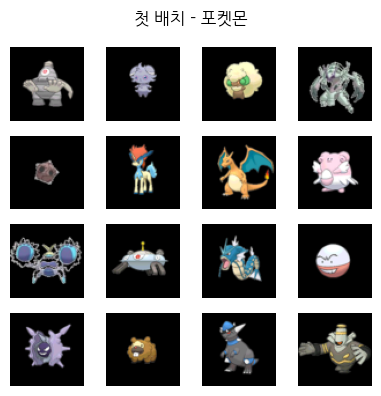

In [ ]:
IMG_SIZE = 64
CHANNELS = 3

class FolderImageDataset(Dataset):
    # 폴더의 이미지 파일을 직접 읽는 커스텀 데이터셋.
    def __init__(self, root, img_size=64, channels=3):
        self.paths = sorted(
            glob.glob(os.path.join(root,"**","*.png"),recursive=True) +
            glob.glob(os.path.join(root,"**","*.jpg"),recursive=True) +
            glob.glob(os.path.join(root,"**","*.jpeg"),recursive=True))
        if not self.paths: raise RuntimeError(f"{root} 에 이미지가 없습니다.")
        self.img_size=img_size; self.channels=channels

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])
        # 투명(RGBA)이면 검정 배경에 합성, 아니면 그대로 RGB
        if img.mode == "RGBA":
            bg = Image.new("RGBA", img.size, (0,0,0,255))
            img = Image.alpha_composite(bg, img)
        img = img.convert("RGB").resize((self.img_size,self.img_size), Image.BILINEAR)
        arr = np.asarray(img, np.float32)/255.0
        arr = arr.transpose(2,0,1)
        x = torch.from_numpy(arr)
        return (x - 0.5)*2.0, 0     # [-1,1]

def show_images(images, title=""):
    # 이미지별 값 범위를 [-1,1]->[0,1] 로 clip 하여 표시.
    if isinstance(images, torch.Tensor): images = images.detach().cpu().numpy()
    imgs = np.clip((images+1)/2, 0, 1)
    n=len(imgs); rows=int(n**0.5); cols=math.ceil(n/rows)
    fig=plt.figure(figsize=(cols,rows))
    for i in range(n):
        ax=fig.add_subplot(rows,cols,i+1)
        ax.imshow(imgs[i].transpose(1,2,0)); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

dataset = FolderImageDataset(DATA_DIR, IMG_SIZE, CHANNELS)
print("데이터셋 크기:", len(dataset))
loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, drop_last=True)
xb,_ = next(iter(loader)); show_images(xb[:16], "첫 배치 - 포켓몬")


### 3. DDPM 모듈 (원본 구조)

In [ ]:
class MyDDPM(nn.Module):
    def __init__(self, network, n_steps=500, min_beta=1e-4, max_beta=0.02,
                 device=None, image_chw=(3,64,64)):
        super().__init__()
        self.n_steps=n_steps; self.device=device; self.image_chw=image_chw
        self.network=network.to(device)
        self.betas=torch.linspace(min_beta,max_beta,n_steps).to(device)
        self.alphas=1-self.betas
        self.alpha_bars=torch.cumprod(self.alphas,dim=0).to(device)
    def forward(self, x0, t, eta=None):
        n,c,h,w=x0.shape; a_bar=self.alpha_bars[t]
        if eta is None: eta=torch.randn(n,c,h,w).to(self.device)
        return a_bar.sqrt().reshape(n,1,1,1)*x0 + (1-a_bar).sqrt().reshape(n,1,1,1)*eta
    def backward(self, x, t): return self.network(x,t)


### 4. 생성 함수 (안정화 샘플링)
매 스텝 예측 x0 를 [-1,1] 로 clamp 하고 posterior 평균으로 샘플링하여 발산을 막는다.

In [ ]:
def generate_new_images(ddpm, n_samples=16, device=None, c=3, h=64, w=64):
    device = device or ddpm.device; ddpm.eval()
    with torch.no_grad():
        x = torch.randn(n_samples,c,h,w).to(device)
        for t in list(range(ddpm.n_steps))[::-1]:
            tt=(torch.ones(n_samples,1)*t).to(device).long()
            eta=ddpm.backward(x,tt)
            a_t=ddpm.alphas[t]; ab_t=ddpm.alpha_bars[t]; b_t=ddpm.betas[t]
            x0_pred=((x-(1-ab_t).sqrt()*eta)/ab_t.sqrt()).clamp(-1,1)
            if t>0:
                ab_prev=ddpm.alpha_bars[t-1]
                cx0=(ab_prev.sqrt()*b_t)/(1-ab_t); cxt=(a_t.sqrt()*(1-ab_prev))/(1-ab_t)
                mean=cx0*x0_pred+cxt*x; var=(1-ab_prev)/(1-ab_t)*b_t
                x=mean+var.sqrt()*torch.randn(n_samples,c,h,w).to(device)
            else:
                x=x0_pred
    return x


### 5. U-Net (원본 MyBlock 기반, 컬러 + 세 변형)

width(채널 폭 배수)와 use_attention(병목 self-attention)으로 구조를 바꾼다.
64×64 입력을 32→16→8 로 줄였다가 복원한다.

In [ ]:
def sinusoidal_embedding(n, d):
    emb=torch.zeros(n,d)
    wk=torch.tensor([1/10_000**(2*j/d) for j in range(d)]).reshape(1,d)
    t=torch.arange(n).reshape(n,1)
    emb[:,::2]=torch.sin(t*wk[:,::2]); emb[:,1::2]=torch.cos(t*wk[:,::2])
    return emb

class MyBlock(nn.Module):
    def __init__(self, shape, in_c, out_c, ks=3, st=1, pad=1, normalize=True):
        super().__init__()
        self.ln=nn.LayerNorm(shape)
        self.conv1=nn.Conv2d(in_c,out_c,ks,st,pad); self.conv2=nn.Conv2d(out_c,out_c,ks,st,pad)
        self.act=nn.SiLU(); self.normalize=normalize
    def forward(self,x):
        out=self.ln(x) if self.normalize else x
        return self.act(self.conv2(self.act(self.conv1(out))))

class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.mha=nn.MultiheadAttention(channels,num_heads,batch_first=True)
        self.ln=nn.LayerNorm(channels)
    def forward(self,x):
        n,c,h,w=x.shape; seq=x.reshape(n,c,h*w).transpose(1,2)
        seq=seq+self.mha(self.ln(seq),self.ln(seq),self.ln(seq))[0]
        return seq.transpose(1,2).reshape(n,c,h,w)

class MyUNet(nn.Module):
    def __init__(self, n_steps=500, time_emb_dim=100, width=1.0, use_attention=False, in_ch=3):
        super().__init__()
        c1,c2,c3=int(10*width),int(20*width),int(40*width)
        self.time_embed=nn.Embedding(n_steps,time_emb_dim)
        self.time_embed.weight.data=sinusoidal_embedding(n_steps,time_emb_dim); self.time_embed.requires_grad_(False)
        def te(d): return nn.Sequential(nn.Linear(time_emb_dim,d),nn.SiLU(),nn.Linear(d,d))
        self.te1=te(in_ch); self.b1=nn.Sequential(MyBlock((in_ch,64,64),in_ch,c1),MyBlock((c1,64,64),c1,c1))
        self.down1=nn.Conv2d(c1,c1,4,2,1)
        self.te2=te(c1); self.b2=nn.Sequential(MyBlock((c1,32,32),c1,c2),MyBlock((c2,32,32),c2,c2))
        self.down2=nn.Conv2d(c2,c2,4,2,1)
        self.te3=te(c2); self.b3=nn.Sequential(MyBlock((c2,16,16),c2,c3),MyBlock((c3,16,16),c3,c3))
        self.down3=nn.Conv2d(c3,c3,4,2,1)
        self.te_mid=te(c3); mid=[MyBlock((c3,8,8),c3,c3)]
        if use_attention: mid.append(SelfAttention(c3))
        mid.append(MyBlock((c3,8,8),c3,c3)); self.b_mid=nn.Sequential(*mid)
        self.up1=nn.ConvTranspose2d(c3,c3,4,2,1)
        self.te4=te(c3*2); self.b4=nn.Sequential(MyBlock((c3*2,16,16),c3*2,c2),MyBlock((c2,16,16),c2,c2))
        self.up2=nn.ConvTranspose2d(c2,c2,4,2,1)
        self.te5=te(c2*2); self.b5=nn.Sequential(MyBlock((c2*2,32,32),c2*2,c1),MyBlock((c1,32,32),c1,c1))
        self.up3=nn.ConvTranspose2d(c1,c1,4,2,1)
        self.te_out=te(c1*2); self.b_out=nn.Sequential(MyBlock((c1*2,64,64),c1*2,c1),MyBlock((c1,64,64),c1,c1,normalize=False))
        self.conv_out=nn.Conv2d(c1,in_ch,3,1,1)
    def forward(self,x,t):
        t=self.time_embed(t); n=len(x)
        o1=self.b1(x+self.te1(t).reshape(n,-1,1,1))
        o2=self.b2(self.down1(o1)+self.te2(t).reshape(n,-1,1,1))
        o3=self.b3(self.down2(o2)+self.te3(t).reshape(n,-1,1,1))
        om=self.b_mid(self.down3(o3)+self.te_mid(t).reshape(n,-1,1,1))
        o4=self.b4(torch.cat((o3,self.up1(om)),1)+self.te4(t).reshape(n,-1,1,1))
        o5=self.b5(torch.cat((o2,self.up2(o4)),1)+self.te5(t).reshape(n,-1,1,1))
        o=self.b_out(torch.cat((o1,self.up3(o5)),1)+self.te_out(t).reshape(n,-1,1,1))
        return self.conv_out(o)


### 6. 학습 루프

In [ ]:
def training_loop(ddpm, loader, n_epochs, optim, device, store_path="ddpm.pt"):
    mse=nn.MSELoss(); best=float("inf"); hist=[]
    for epoch in tqdm(range(n_epochs), desc="학습 진행"):
        ep=0.0
        for batch in loader:
            x0=batch[0].to(device); n=len(x0)
            eta=torch.randn_like(x0).to(device); t=torch.randint(0,ddpm.n_steps,(n,)).to(device)
            loss=mse(ddpm.backward(ddpm(x0,t,eta), t.reshape(n,-1)), eta)
            optim.zero_grad(); loss.backward(); optim.step()
            ep+=loss.item()*len(x0)/len(loader.dataset)
        hist.append(ep)
        msg=f"에폭 {epoch+1} 손실: {ep:.4f}"
        if ep<best: best=ep; torch.save(ddpm.state_dict(),store_path); msg+="  --> 저장"
        print(msg)
    return hist


### 7. 세 모델 학습 및 비교

컬러·복잡 데이터이므로 에폭을 비교적 넉넉히, n_steps 는 학습 시간과 안정성을 고려해 500.

In [ ]:
n_steps=500; n_epochs=120; lr=1e-3
variants={"A_baseline":dict(width=1.0,use_attention=False),
          "B_wide":dict(width=2.0,use_attention=False),
          "C_attention":dict(width=1.0,use_attention=True)}
results={}
for name,cfg in variants.items():
    print(f"\n===== {name}: {cfg} =====")
    net=MyUNet(n_steps,width=cfg["width"],use_attention=cfg["use_attention"],in_ch=CHANNELS)
    ddpm=MyDDPM(net,n_steps=n_steps,device=device,image_chw=(CHANNELS,IMG_SIZE,IMG_SIZE))
    npar=sum(p.numel() for p in ddpm.parameters())
    hist=training_loop(ddpm,loader,n_epochs,Adam(ddpm.parameters(),lr),device,f"ddpm_{name}.pt")
    results[name]=dict(ddpm=ddpm,params=npar,loss=hist)
    print(f"{name}: 파라미터 {npar:,}, 최종 손실 {hist[-1]:.4f}")



===== A_baseline: {'width': 1.0, 'use_attention': False} =====


학습 진행:   0%|          | 0/120 [00:00<?, ?it/s]

에폭 1 손실: 0.9498  --> 저장
에폭 2 손실: 0.9278  --> 저장
에폭 3 손실: 0.8573  --> 저장
에폭 4 손실: 0.7615  --> 저장
에폭 5 손실: 0.6964  --> 저장
에폭 6 손실: 0.6469  --> 저장
에폭 7 손실: 0.5820  --> 저장
에폭 8 손실: 0.5110  --> 저장
에폭 9 손실: 0.4597  --> 저장
에폭 10 손실: 0.4208  --> 저장
에폭 11 손실: 0.3905  --> 저장
에폭 12 손실: 0.3652  --> 저장
에폭 13 손실: 0.3476  --> 저장
에폭 14 손실: 0.3067  --> 저장
에폭 15 손실: 0.2797  --> 저장
에폭 16 손실: 0.2450  --> 저장
에폭 17 손실: 0.2135  --> 저장
에폭 18 손실: 0.1974  --> 저장
에폭 19 손실: 0.1780  --> 저장
에폭 20 손실: 0.1671  --> 저장
에폭 21 손실: 0.1523  --> 저장
에폭 22 손실: 0.1359  --> 저장
에폭 23 손실: 0.1340  --> 저장
에폭 24 손실: 0.1156  --> 저장
에폭 25 손실: 0.1156  --> 저장
에폭 26 손실: 0.1098  --> 저장
에폭 27 손실: 0.1251
에폭 28 손실: 0.1100
에폭 29 손실: 0.0963  --> 저장
에폭 30 손실: 0.0930  --> 저장
에폭 31 손실: 0.0925  --> 저장
에폭 32 손실: 0.0849  --> 저장
에폭 33 손실: 0.0895
에폭 34 손실: 0.0891
에폭 35 손실: 0.0843  --> 저장
에폭 36 손실: 0.0808  --> 저장
에폭 37 손실: 0.0817
에폭 38 손실: 0.0780  --> 저장
에폭 39 손실: 0.0824
에폭 40 손실: 0.0791
에폭 41 손실: 0.0952
에폭 42 손실: 0.0811
에폭 43 손실: 0.0797
에폭 44 손실: 0.07

학습 진행:   0%|          | 0/120 [00:00<?, ?it/s]

에폭 1 손실: 0.9312  --> 저장
에폭 2 손실: 0.7605  --> 저장
에폭 3 손실: 0.5343  --> 저장
에폭 4 손실: 0.3976  --> 저장
에폭 5 손실: 0.2697  --> 저장
에폭 6 손실: 0.1932  --> 저장
에폭 7 손실: 0.1507  --> 저장
에폭 8 손실: 0.1351  --> 저장
에폭 9 손실: 0.1197  --> 저장
에폭 10 손실: 0.1157  --> 저장
에폭 11 손실: 0.1061  --> 저장
에폭 12 손실: 0.1043  --> 저장
에폭 13 손실: 0.0958  --> 저장
에폭 14 손실: 0.0890  --> 저장
에폭 15 손실: 0.0975
에폭 16 손실: 0.0857  --> 저장
에폭 17 손실: 0.0831  --> 저장
에폭 18 손실: 0.0766  --> 저장
에폭 19 손실: 0.0777
에폭 20 손실: 0.0726  --> 저장
에폭 21 손실: 0.0793
에폭 22 손실: 0.0681  --> 저장
에폭 23 손실: 0.0653  --> 저장
에폭 24 손실: 0.0633  --> 저장
에폭 25 손실: 0.0649
에폭 26 손실: 0.0717
에폭 27 손실: 0.0643
에폭 28 손실: 0.0591  --> 저장
에폭 29 손실: 0.0577  --> 저장
에폭 30 손실: 0.0632
에폭 31 손실: 0.0523  --> 저장
에폭 32 손실: 0.0576
에폭 33 손실: 0.0500  --> 저장
에폭 34 손실: 0.0501
에폭 35 손실: 0.0475  --> 저장
에폭 36 손실: 0.0468  --> 저장
에폭 37 손실: 0.0464  --> 저장
에폭 38 손실: 0.0442  --> 저장
에폭 39 손실: 0.0432  --> 저장
에폭 40 손실: 0.0424  --> 저장
에폭 41 손실: 0.0423  --> 저장
에폭 42 손실: 0.0408  --> 저장
에폭 43 손실: 0.0420
에폭 44 손실: 0.03

학습 진행:   0%|          | 0/120 [00:00<?, ?it/s]

에폭 1 손실: 0.9476  --> 저장
에폭 2 손실: 0.9114  --> 저장
에폭 3 손실: 0.8241  --> 저장
에폭 4 손실: 0.7079  --> 저장
에폭 5 손실: 0.6317  --> 저장
에폭 6 손실: 0.5635  --> 저장
에폭 7 손실: 0.4912  --> 저장
에폭 8 손실: 0.4407  --> 저장
에폭 9 손실: 0.3969  --> 저장
에폭 10 손실: 0.3603  --> 저장
에폭 11 손실: 0.3151  --> 저장
에폭 12 손실: 0.2639  --> 저장
에폭 13 손실: 0.2263  --> 저장
에폭 14 손실: 0.1939  --> 저장
에폭 15 손실: 0.1694  --> 저장
에폭 16 손실: 0.1493  --> 저장
에폭 17 손실: 0.1437  --> 저장
에폭 18 손실: 0.1292  --> 저장
에폭 19 손실: 0.1323
에폭 20 손실: 0.1254  --> 저장
에폭 21 손실: 0.1181  --> 저장
에폭 22 손실: 0.1113  --> 저장
에폭 23 손실: 0.1011  --> 저장
에폭 24 손실: 0.1014
에폭 25 손실: 0.1019
에폭 26 손실: 0.0943  --> 저장
에폭 27 손실: 0.0975
에폭 28 손실: 0.0956
에폭 29 손실: 0.0912  --> 저장
에폭 30 손실: 0.0885  --> 저장
에폭 31 손실: 0.0843  --> 저장
에폭 32 손실: 0.0837  --> 저장
에폭 33 손실: 0.0817  --> 저장
에폭 34 손실: 0.0879
에폭 35 손실: 0.0740  --> 저장
에폭 36 손실: 0.0785
에폭 37 손실: 0.0757
에폭 38 손실: 0.0765
에폭 39 손실: 0.0714  --> 저장
에폭 40 손실: 0.0726
에폭 41 손실: 0.0748
에폭 42 손실: 0.0681  --> 저장
에폭 43 손실: 0.0697
에폭 44 손실: 0.0633  --> 저장
에폭 45

### 7.1 손실 곡선 / 파라미터

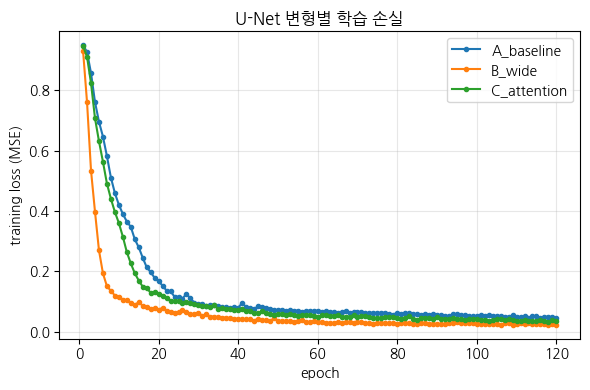

A_baseline    : 파라미터 918,274
B_wide        : 파라미터 2,235,654
C_attention   : 파라미터 924,914


In [ ]:
plt.figure(figsize=(6,4))
for name,r in results.items():
    plt.plot(range(1,len(r["loss"])+1), r["loss"], marker="o", ms=3, label=name)
plt.xlabel("epoch"); plt.ylabel("training loss (MSE)")
plt.title("U-Net 변형별 학습 손실"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("loss_curves.png",dpi=120); plt.show()
for name,r in results.items(): print(f"{name:14s}: 파라미터 {r['params']:,}")


### 7.2 생성 샘플 비교

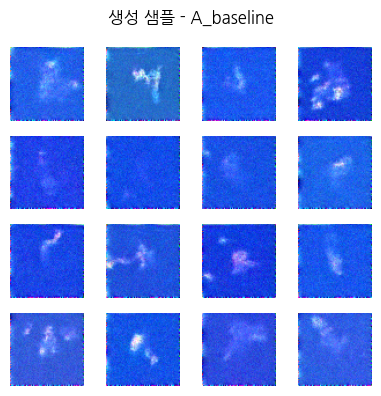

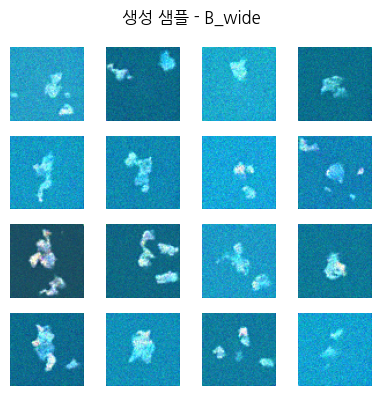

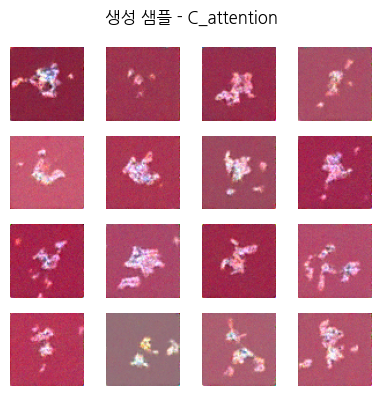

In [ ]:
for name,r in results.items():
    gen=generate_new_images(r["ddpm"],16,device,CHANNELS,IMG_SIZE,IMG_SIZE)
    show_images(gen, f"생성 샘플 - {name}")
